In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

file_path = '../dataset/job_salary_prediction_dataset.csv'

df = pd.read_csv(file_path)

df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [2]:
print(df.isna().mean()*100) #data is already clean

job_title           0.0
experience_years    0.0
education_level     0.0
skills_count        0.0
industry            0.0
company_size        0.0
location            0.0
remote_work         0.0
certifications      0.0
salary              0.0
dtype: float64


In [3]:
df.shape

(250000, 10)

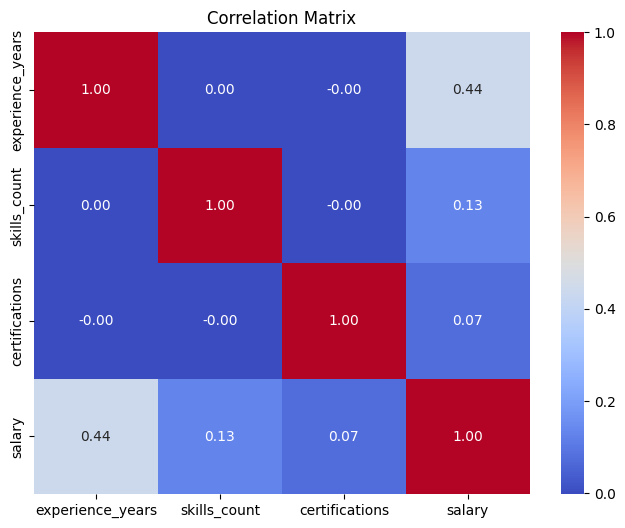

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df[['experience_years', 'skills_count', 'certifications', 'salary']]

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

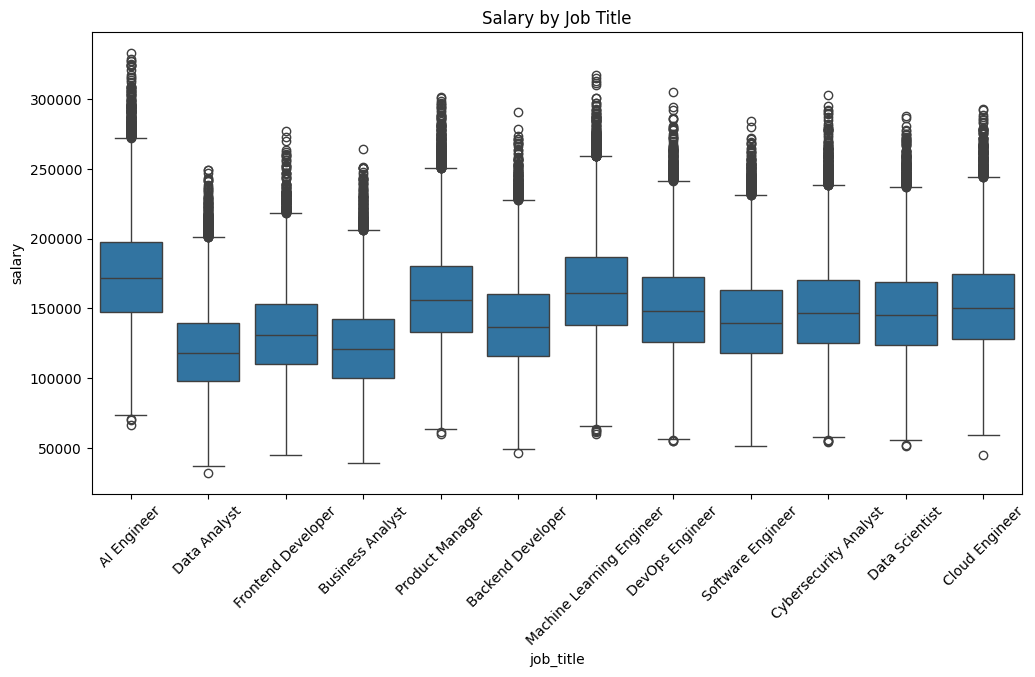

In [5]:
plt.figure(figsize=(12,6))

sns.boxplot(x='job_title', y='salary', data=df)

plt.xticks(rotation=45)
plt.title("Salary by Job Title")
plt.show()

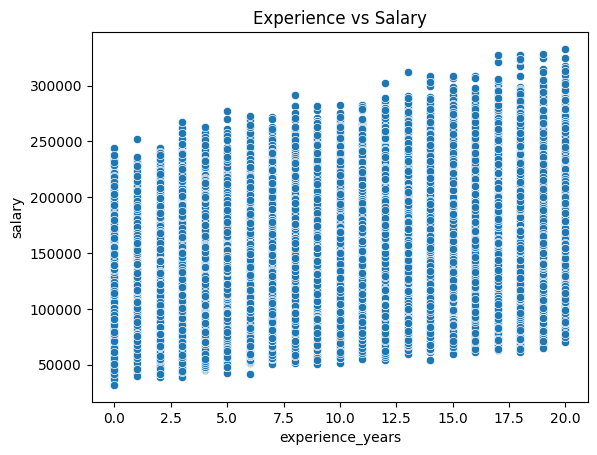

In [6]:
sns.scatterplot(x='experience_years', y='salary', data=df)
plt.title("Experience vs Salary")
plt.show()

In [7]:
from sklearn.model_selection import train_test_split

target_col = 'salary'
X = df.drop(columns=[target_col])
y = df[target_col]

categorical_cols = [
    'job_title', 
    'education_level', 
    'industry', 
    'company_size', 
    'location', 
    'remote_work'
]
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print(f"Original features: {X.shape[1]}")
print(f"Features after encoding: {X_train.shape[1]}")

Original features: 9
Features after encoding: 42


In [8]:
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
import joblib

data_folder = '../data'
model_path = os.path.join(data_folder, 'salary_prediction_model.pkl')

if os.path.exists(model_path):
    os.remove(model_path)
    print(f"Old model found and deleted from: {model_path}")
else:
    print("No old model found. Proceeding with fresh training.")

print("Training model... this might take a few seconds.")
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("\n--- Model Performance ---")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-squared Score: {r2:.3f}")


os.makedirs(data_folder, exist_ok=True)

joblib.dump(model, model_path)
print(f"\nModel successfully saved to '{model_path}'")

Old model found and deleted from: ../data\salary_prediction_model.pkl
Training model... this might take a few seconds.

--- Model Performance ---
Mean Absolute Error (MAE): $5,693.02
Root Mean Squared Error (RMSE): $7,375.76
R-squared Score: 0.961

Model successfully saved to '../data\salary_prediction_model.pkl'
